# Day 3 — Dimensionality Reduction with PCA

## Objectives

- Explain the curse of dimensionality and why dimensionality reduction is useful.
- Apply Principal Component Analysis (PCA) to reduce the dimensions of a dataset.
- Interpret explained variance.
- Choose the number of components needed to retain approximately 95% of the variance.
- Visualize the dataset after reducing it to two principal components.

## 1. The Curse of Dimensionality

As the number of features in a dataset increases, the data becomes more
sparse and difficult to analyze.

High dimensionality can cause several problems:

- Distances between observations become less meaningful.
- Models may become more likely to overfit.
- Computation can become more expensive.
- High-dimensional data cannot be easily visualized.

Dimensionality reduction helps simplify the dataset by reducing the
number of features while preserving as much important information as
possible.

## 2. What is PCA?

Principal Component Analysis (PCA) is a dimensionality reduction
technique that transforms the original features into new features called
principal components.

The first principal component captures the greatest amount of variance
in the data.

The second principal component captures the next greatest amount of
variance while remaining independent from the first component.

By keeping only the most important components, PCA reduces the number of
dimensions while retaining most of the information in the dataset.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv(
    r"D:\Desktop\AI & ML BinX Tech\Python\Week 1\tested.csv"
)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
features = ["Pclass", "Age", "SibSp", "Parch", "Fare"]

X = df[features].copy()

X.head()

,Pclass,Age,SibSp,Parch,Fare
0,3,34.5,0,0,7.8292
1,3,47.0,1,0,7.0000
2,2,62.0,0,0,9.6875
3,3,27.0,0,0,8.6625
4,3,22.0,1,1,12.2875


In [6]:
X.isnull().sum()

Pclass     0
Age       86
SibSp      0
Parch      0
Fare       1
dtype: int64

## 3. Feature Scaling

PCA is based on variance, so features must be standardized before
applying PCA.

Without scaling, features with larger numerical ranges could dominate
the principal components.

In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 0.87348191,  0.29854934, -0.49947002, -0.4002477 , -0.49781052],
       [ 0.87348191,  1.18132793,  0.61699237, -0.4002477 , -0.51265996],
       [-0.31581919,  2.24066224, -0.49947002, -0.4002477 , -0.46453181],
       [ 0.87348191, -0.23111782, -0.49947002, -0.4002477 , -0.48288766],
       [ 0.87348191, -0.58422925,  0.61699237,  0.61989583, -0.41797062]])

In [8]:
X = X.fillna(X.median())

In [9]:
print(X.isnull().sum())
print("Total missing values:", X.isnull().sum().sum())

Pclass    0
Age       0
SibSp     0
Parch     0
Fare      0
dtype: int64
Total missing values: 0


In [10]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 0.87348191,  0.38623105, -0.49947002, -0.4002477 , -0.49741333],
       [ 0.87348191,  1.37137004,  0.61699237, -0.4002477 , -0.51227801],
       [-0.31581919,  2.55353683, -0.49947002, -0.4002477 , -0.46410047],
       [ 0.87348191, -0.20485235, -0.49947002, -0.4002477 , -0.48247516],
       [ 0.87348191, -0.59890794,  0.61699237,  0.61989583, -0.4174915 ]])

In [11]:
pca = PCA()

X_pca_all = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_

explained_variance

array([0.39077774, 0.27592741, 0.1394256 , 0.12148168, 0.07238757])

In [12]:
cumulative_variance = np.cumsum(explained_variance)

for i, variance in enumerate(cumulative_variance, start=1):
    print(f"{i} components: {variance:.4f} ({variance:.2%})")

1 components: 0.3908 (39.08%)
2 components: 0.6667 (66.67%)
3 components: 0.8061 (80.61%)
4 components: 0.9276 (92.76%)
5 components: 1.0000 (100.00%)


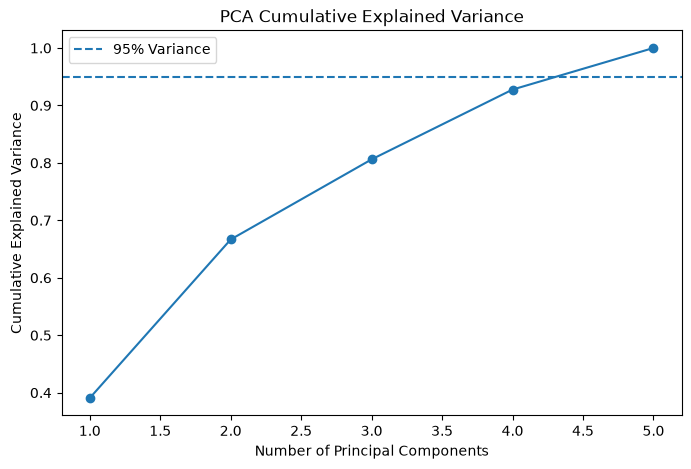

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    y=0.95,
    linestyle="--",
    label="95% Variance"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")

plt.legend()
plt.show()

## 4. Choosing the Number of Components

The cumulative explained variance shows how much of the original variance
is retained as more principal components are included.

In this dataset:

- 1 component retains approximately 39.08% of the variance.
- 2 components retain approximately 66.67%.
- 3 components retain approximately 80.61%.
- 4 components retain approximately 92.76%.
- 5 components retain 100%.

Therefore, retaining approximately 95% of the variance requires all 5
components in this dataset.

Although PCA does not provide a strong dimensionality reduction at the
95% threshold here, reducing the data to 2 components is useful for
visualization.

In [14]:
pca_2 = PCA(n_components=2)

X_pca_2 = pca_2.fit_transform(X_scaled)

print("Shape before PCA:", X_scaled.shape)
print("Shape after PCA:", X_pca_2.shape)

Shape before PCA: (418, 5)
Shape after PCA: (418, 2)


In [15]:
explained_2 = pca_2.explained_variance_ratio_

print("PC1 variance:", explained_2[0])
print("PC2 variance:", explained_2[1])
print("Total variance retained:", explained_2.sum())

PC1 variance: 0.3907777379023713
PC2 variance: 0.27592741178234087
Total variance retained: 0.6667051496847122


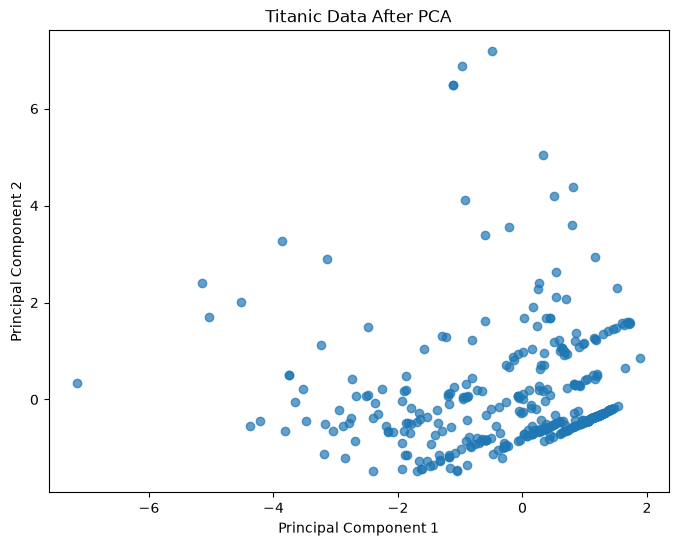

In [16]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca_2[:, 0],
    X_pca_2[:, 1],
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Titanic Data After PCA")

plt.show()

## 5. PCA Results and Interpretation

PCA reduced the original 5 numerical features to 2 principal components
for visualization.

The first principal component explains approximately 39.08% of the total
variance, while the second explains approximately 27.59%.

Together, the first two principal components retain approximately 66.67%
of the total variance.

This reduction makes the dataset easier to visualize in two dimensions
while preserving a substantial portion of its overall variation.

However, approximately 33.33% of the variance is not represented by the
first two components. Therefore, the 2-component representation is useful
for visualization, but it does not preserve all of the information in the
original dataset.

The main trade-off is that principal components are combinations of the
original features, making them less directly interpretable than the
original variables.